**Step-1 : Import Required Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

**Step-2: Create a Dataset**

In [ ]:
X, y = make_blobs(
    n_samples = 300,
    n_features = 2,
    centers = 4,
    cluster_std = 1.0,
    random_state = 42
)

print("Dataset shape : ", X.shape)

Dataset shape :  (300, 2)


**Step-3 : Convert the Dataset into a DataFrame**

In [ ]:
df = pd.DataFrame(X, columns = ["Feature 1", "Feature 2"])
df.head()

,Feature 1,Feature 2
0,-9.297689,6.473679
1,-9.698741,6.938967
2,-1.686653,7.793442
3,-7.097308,-5.781333
4,-10.876452,6.315437


**Step-4: Vistualize the Orginal Data**

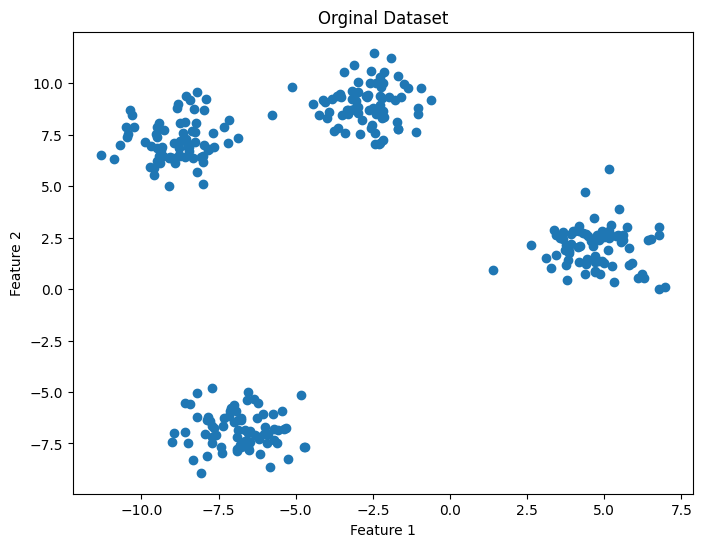

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["Feature 1"],
    df["Feature 2"]
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Orginal Dataset")

plt.show()

**Step-5: K-Means (Try K = 2, 3, 4, 5)**

In [ ]:
k_values = [2, 3, 4, 5]
results = {}

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X)
    results[k] = {
        "model": kmeans,
        "labels": labels,
        "centroids": kmeans.cluster_centers_
    }

print("Cluster labels for K = 2: ", results[2]["labels"][:10])
print("Centroids for K = 2: ")
print(results[2]["centroids"])
print("-" * 40)

for k in k_values:
    print(f"K = {k}")

    print(results[k]["centroids"])
    print("-" * 40)

Cluster labels for K = 2:  [0 0 0 1 0 1 0 1 0 0]
Centroids for K = 2: 
[[-2.26099839  6.07059051]
 [-6.83235205 -6.83045748]]
----------------------------------------
K = 2
[[-2.26099839  6.07059051]
 [-6.83235205 -6.83045748]]
----------------------------------------
K = 3
[[-5.75060003  8.08498739]
 [-6.83235205 -6.83045748]
 [ 4.7182049   2.04179676]]
----------------------------------------
K = 4
[[-2.70981136  8.97143336]
 [-6.83235205 -6.83045748]
 [ 4.7182049   2.04179676]
 [-8.87357218  7.17458342]]
----------------------------------------
K = 5
[[-7.95710161  8.35464604]
 [-6.83235205 -6.83045748]
 [ 4.7182049   2.04179676]
 [-9.12890818  6.79685708]
 [-2.66914955  8.97847783]]
----------------------------------------


**Step-6 : Visualize K = 2, 3, 4, 5**

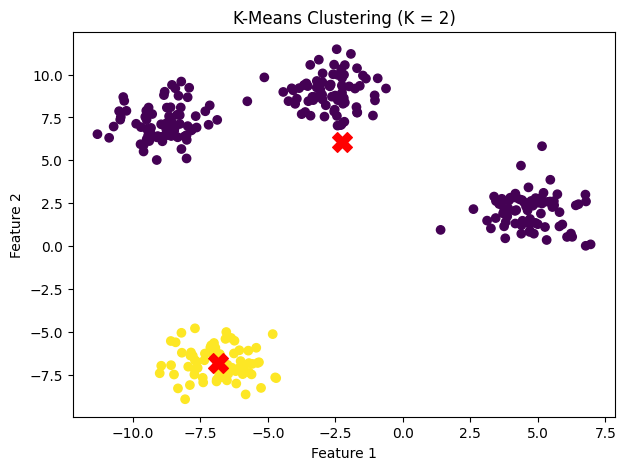

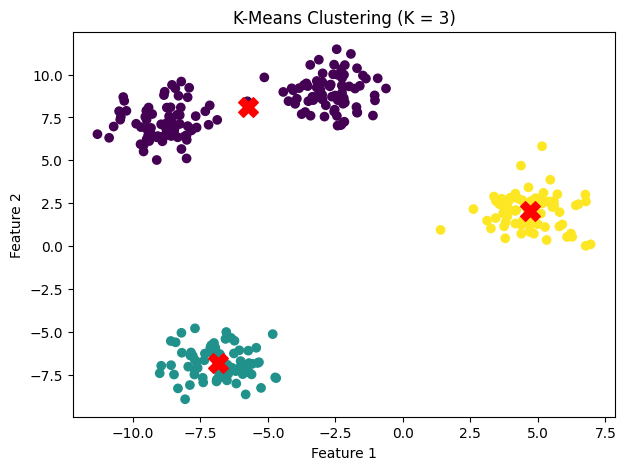

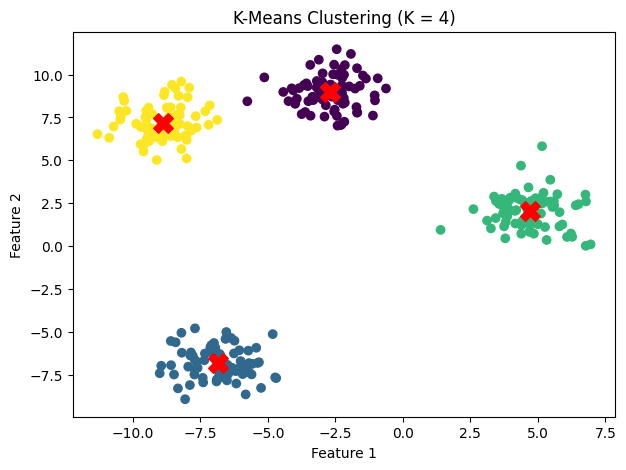

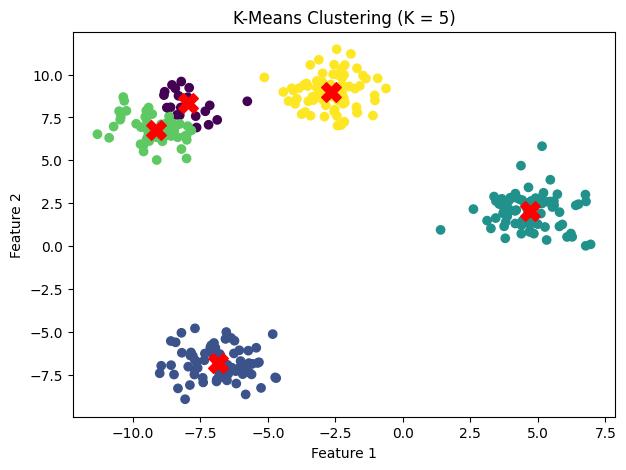

In [ ]:
for k in k_values:
    labels = results[k]["labels"]
    centroids = results[k]["centroids"]

    plt.figure(figsize=(7, 5))
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="viridis")
    plt.scatter(centroids[:, 0], centroids[:, 1], c="red", marker="X", s=200)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(f"K-Means Clustering (K = {k})")
    plt.show()

**Step-7 : Elbow Method**

In [ ]:
inertia_values = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X)
    inertia_values.append(kmeans.inertia_)

print("Inertia values:", inertia_values)

Inertia values: [19953.769148278025, 9416.214004352278, 2110.4125218953286, 564.9141808210254, 512.3903339109638, 460.30790312355344, 408.9473812641574, 360.8214343877636, 325.372688355219, 291.5608624106774]


**Step-8 : Create the Elbow Graph**

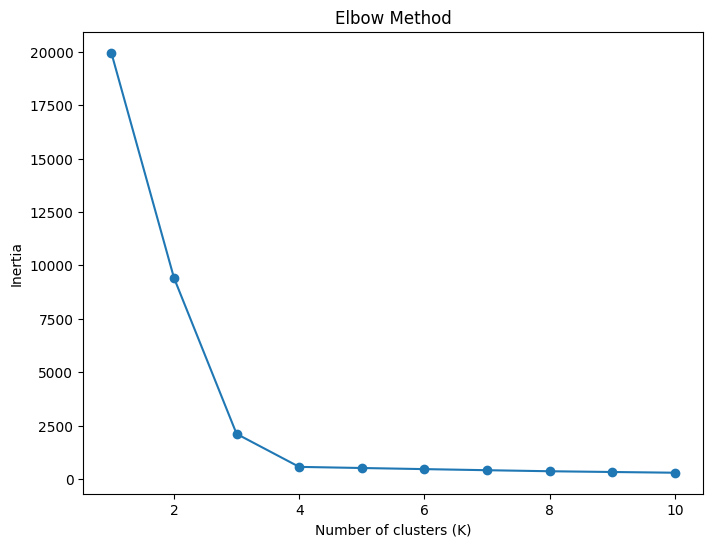

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), inertia_values, marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

**Step-9 : Calculate Silhouette Score**

In [ ]:
# Create a dictionary to store the silhouette score for each K
silhouette_scores = {}

# Calculate the silhouette score for K = 2, 3, 4 and 5
for k in k_values:
  kmeans = KMeans(
      n_clusters = k,
      random_state = 42,
      n_init = 10
  )

  # Fit the model and obtain the cluster label for each data point,
  labels = kmeans.fit_predict(X)

  # Calculate the score for the current clustering result.
  score = silhouette_score(X, labels)

  # Calculate the score using the current K as the dictionary key
  silhouette_scores[k] = score

  # Print the K value and Silhouette Score rounded to four decimal places.
  print(
      f"k = {k},"
      f"Silhouette Score = {score: .4f}"
  )

k = 2,Silhouette Score =  0.5902
k = 3,Silhouette Score =  0.7569
k = 4,Silhouette Score =  0.7916
k = 5,Silhouette Score =  0.6890


**Step-10 : Visualize the Silhouette Score**

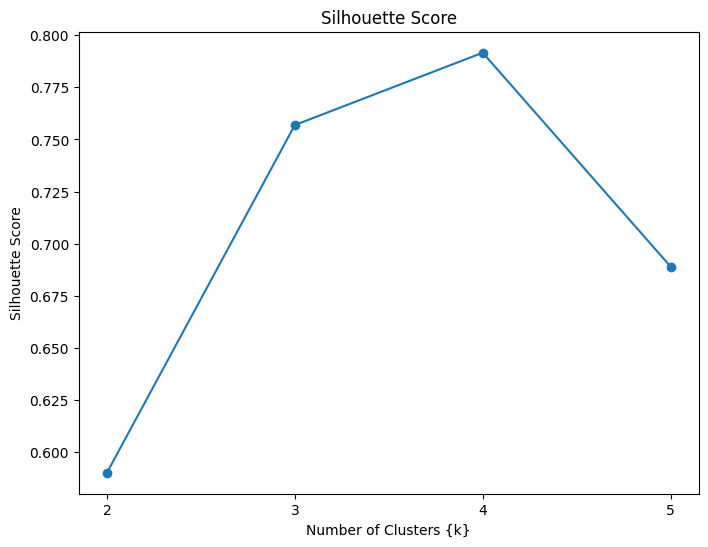

In [ ]:
# Create a figure for the Silhouette Score plot.
plt.figure(figsize=(8, 6))

# Plot the relationship between K and Silhouette Score.
plt.plot(
    list(silhouette_scores.keys()),
    list(silhouette_scores.values()),
    marker = "o"
)

# Label the X-axis as the numbers of clusters.
plt.xlabel("Number of Clusters {k}")
# Label the Y-axis as the Silhouette Score.
plt.ylabel("Silhouette Score")
# Set the title of the Silhouette Score graph.
plt.title("Silhouette Score")
# Show K values 2, 3, 4, and 5 on the X-axis
plt.xticks(k_values)
# Display the Silhouette Score graph.
plt.show()

**Step-11 : Select the Final Best K**



In [ ]:
# Select the K value with highest Silhouette Score.
best_k = max(
    silhouette_scores,
    key = silhouette_scores.get
)

# Display the best K selected based on the Silhouette Score.
print("\nBest K based on Silhouette Score : ", best_k)


Best K based on Silhouette Score :  4


**Step-12 : Train the Final Model**

In [ ]:
# Create the final K-Means model using the best K.
final_kmeans = KMeans(
    n_clusters = 4,
    random_state = 42,
    n_init = 10
)

# Fit the final K-Means model and obtain the final cluster labels.
final_labels = final_kmeans.fit_predict(X)
# Retrieve the centroid coordinates form the model.
final_centroids = final_kmeans.cluster_centers_

**Step-13 : Display Cluster Labels**

In [ ]:
# Add the final cluster labels as a new column in the DataFrame.
df["Final Clusters"] = final_labels

# Print a message indicating that the labeled dataset will be displayed.
print("\nDataset with Cluster Labels : ")

# Display the first 10 rows of the DataFrame.
display(df.head(10))



Dataset with Cluster Labels : 


,Feature 1,Feature 2,Final Clusters
0,-9.297689,6.473679,3
1,-9.698741,6.938967,3
2,-1.686653,7.793442,0
3,-7.097308,-5.781333,1
4,-10.876452,6.315437,3
5,-6.021968,-7.040048,1
6,4.813060,2.358487,2
7,-6.466696,-7.443834,1
8,-2.988372,8.828627,0
9,3.448575,2.629723,2


**Step-14 : Display Final Centroids**

In [ ]:
print("\nFinal Centroids")

# Loop through each centroid together with its index.
for i, centroid in enumerate(final_centroids):

  # Display each cluster's feature 1 and feature 2 centroid coordinates with formatting
  print(
      f"Cluster {i} :"
      f"Feature 1 = {centroid[0]: .2f}"
      f"Feature 2 = {centroid[1]: .2f}"

  )


Final Centroids
Cluster 0 :Feature 1 = -2.71Feature 2 =  8.97
Cluster 1 :Feature 1 = -6.83Feature 2 = -6.83
Cluster 2 :Feature 1 =  4.72Feature 2 =  2.04
Cluster 3 :Feature 1 = -8.87Feature 2 =  7.17


**Step-15 : Final Cluster Visualization**

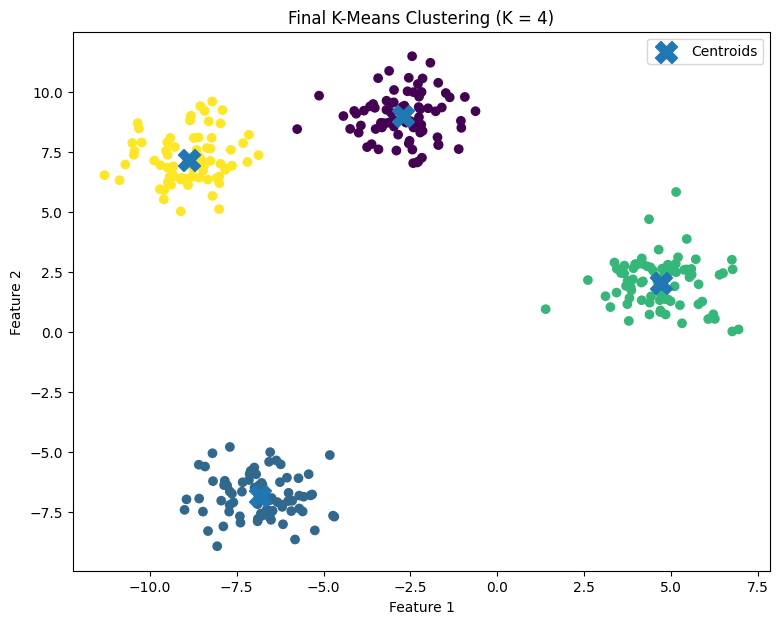

In [ ]:
# Create a figure for the final clustering visualization.
plt.figure(figsize=(9,7))

# Plot the data points according to the final Custer labels.
plt.scatter(
    X[:, 0],
    X[:, 1],
    c = final_labels
)

# HighLight the final centroid
plt.scatter(
    final_centroids[:, 0],
    final_centroids[:, 1],
    marker = "X",
    s = 250,
    label = "Centroids"
)

# Set the X-label, Y-label and title
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title(f"Final K-Means Clustering (K = {best_k})")

#Display the legend for the centroids
plt.legend()

# Displat the final Clustering graph
plt.show()

**Step- 16 : Cluster Size**

In [ ]:
print("\nNumber of data prints in each cluster : ")

# Count the data point in each cluster and sort the result by cluster number.
print(
    df["Final Clusters"]
    .value_counts()
    .sort_index()
)


Number of data prints in each cluster : 
Final Clusters
0    76
1    75
2    75
3    74
Name: count, dtype: int64
